In [ ]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt

traffic_df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")
traffic_df = pd.DataFrame(traffic_df)

y = traffic_df['traffic_volume']
X = traffic_df.drop('traffic_volume', axis=1)
traffic_df['date_time'] = pd.to_datetime(traffic_df['date_time'], format='%d-%m-%Y %H:%M')
traffic_df['hour']=traffic_df['date_time'].dt.hour
#traffic_df['dayOfWeek']=traffic_df['date_time'].dt.weekday
traffic_df['isWeekend'] = (traffic_df['date_time'].dt.weekday >= 5).astype(int)
traffic_df.head(10)

# Dataset analysis and preparation
Since the data is not all numbers, it is required to convert the qualitative categories into quantitative lists.

In [ ]:
traffic_df['holiday'].unique()

traffic_df['isHoliday'] = pd.notna(traffic_df['holiday']).astype('int')
print(traffic_df['weather_main'].unique())
# Maybe needed to adapt the order to make sense to the description.
unique_weathers = traffic_df['weather_main'].values
#df['weather_cat'] = pd.factorize(unique_weathers)[0]
weather_encoded = pd.get_dummies(traffic_df['weather_main'], prefix='weather').astype('int')

traffic_df = pd.concat([traffic_df, weather_encoded], axis=1)
traffic_df.head(10)

Visualization

In [ ]:
print(traffic_df.head())
#traffic_df.set_index('date_time', inplace = True) # à run qu'une seule fois par df ? jsp pq
plt.plot(traffic_df.index,
         traffic_df['traffic_volume'],
         linewidth = 0.1)
plt.title("Traffic Volume Across Time")
plt.show()


First attempt with the dataset : use only quantitative data

In [ ]:
Xp = traffic_df.drop('weather_main', axis=1)
Xp = Xp.drop('date_time', axis=1)
Xp = Xp.drop('weather_description', axis=1)
Xp = Xp.drop('holiday', axis=1)
yp = traffic_df['traffic_volume']
Xp = Xp.drop('traffic_volume', axis=1)
#Xp = Xp.drop('dayOfWeek', axis=1)

print(np.array(Xp))
Xp.describe()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

df_pca = pd.concat([Xp, yp], axis=1)
X_pca = np.array(df_pca)
traffic_features = df_pca.columns.values
print(traffic_features)
n_features = traffic_features.size

scaler = StandardScaler()
D0 = scaler.fit_transform(X_pca)
pca = PCA(n_components=n_features)
pca.fit(D0)

A = pca.components_.T
Z = D0 @ A

i, j = 0, 3

plt.figure()
plt.scatter(Z[:, i], Z[:, j], c='w')
plt.xlabel(f'PC {i+1}')
plt.ylabel(f'PC {j+1}')
plt.show()

eigenvector_i = 1 # Take the first one

plt.figure()
plt.bar(np.arange(n_features), A[:, eigenvector_i])
plt.xticks(np.arange(n_features), traffic_features, rotation=90)
plt.ylabel(f'{eigenvector_i+1} eigenvector weight')
plt.show()

df_pca = pd.DataFrame(X_pca, columns=traffic_features)
print(df_pca.describe())
corr_mat = sns.heatmap(df_pca.corr())
plt.show()

ex_var = pca.explained_variance_ratio_
cum_ex_var = np.cumsum(ex_var)

plt.figure()
plt.plot(ex_var, marker='o', markerfacecolor='none', color='r', linewidth=1, label='expl. var.')
plt.plot(cum_ex_var, marker='o', markerfacecolor='none', color='k', linewidth=1, label='cum. expl. var.')
plt.legend()
plt.show()


We see that for this dataset, the impact of the day of the week is very week, meaning that traffic is always the same on every day, hence, we can use only the hour from that scope. Holiday is also very week.

For the rest, the most significant parameters are the temp, the clouds and the snow.

Let us know see whether the other categories describing the weather qualitatively are relevant to this study.

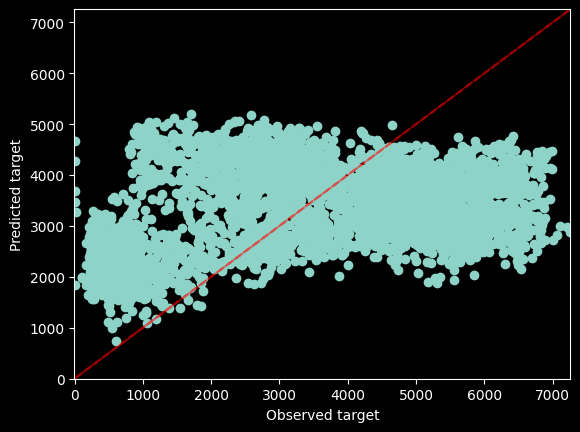

In [130]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(Xp, np.array(yp).reshape(-1,1), test_size=0.1, random_state=1)
scalerX = StandardScaler()
scalery = StandardScaler()

X0_train = scalerX.fit_transform(X_train)
X0_test = scalerX.transform(X_test)

# y0_train = scalery.fit_transform(y_train)
# y0_test = scalery.transform(y_test)

# Create the linear regression object
OLS_reg = LinearRegression().fit(X0_train, y_train)

# To test the regression, we need to scale and center also the test data

y_pred_OLS = OLS_reg.predict(X0_test)

plt.scatter(y_test, y_pred_OLS)
plt.plot(y_test, y_test, c='r', alpha=0.6, ls='--')
plt.xlim(y_test.min()-2, y_test.max()+2)
plt.ylim(y_test.min()-2, y_test.max()+2)
plt.xlabel('Observed target')
plt.ylabel('Predicted target')
plt.show()

/Users/emilakariou/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_coordinate_descent.py:1664: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


R2: 0.15329693334266115
RMSE: 1836.5077946010042
hour                    648.297051
dayOfWeek              -285.891407
temp                    196.954231
weather_Clouds          147.945889
clouds_all               69.690798
weather_Haze             58.377159
isHoliday               -48.988822
weather_Thunderstorm    -48.828961
weather_Mist            -22.836626
weather_Fog             -12.032987
weather_Squall           -3.912349
snow_1h                  -2.175047
rain_1h                   0.000000
weather_Clear             0.000000
weather_Drizzle           0.000000
weather_Rain             -0.000000
weather_Snow             -0.000000
weather_Smoke            -0.000000
dtype: float64


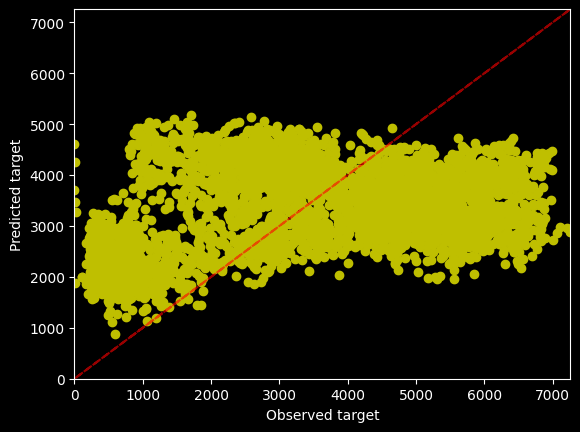

In [131]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, mean_squared_error
#print(y0_train)
#print(y0_train.flatten())
LassoCV_reg = LassoCV(cv=10, random_state=42).fit(X0_train, y_train) # Bizarre qu'il faille mettre une tol aussi basse...
y_pred_lassoCV = LassoCV_reg.predict(X0_test)

print("R2:", r2_score(y_test, y_pred_lassoCV))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lassoCV)))

coefficients = pd.Series(LassoCV_reg.coef_, index=Xp.columns)
print(coefficients.sort_values(key=abs, ascending=False))

plt.scatter(y_test, y_pred_lassoCV, c='y', alpha = 1)
plt.plot(y_test, y_test, c='r', alpha=0.6, ls='--')
plt.xlim(y_test.min()-1, y_test.max()+1)
plt.ylim(y_test.min()-1, y_test.max()+1)
plt.xlabel('Observed target')
plt.ylabel('Predicted target')
plt.show()